### This notebook is about learning Autograd in Pytorch

---
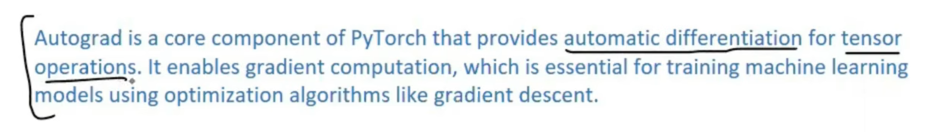
---

In [2]:
### Without Autograd
def diff(value):
    # for y = x^2
    dy_dx = 2*(value)
    return dy_dx


diff(3)

6

### AutoGrad Workflow

In [2]:
import torch

### Example 1

In [4]:
# use of requires_grad = True
x = torch.tensor(3.0 , requires_grad=True) # this tells pytorch that create gradients as we move ahead beforehand

In [5]:
# Now we did some mathematical operation like 
y = x**3

In [7]:
print(y) # see it prints the resulting tensor, as well as creates a gradient function that is helpful in back propagation

tensor(27., grad_fn=<PowBackward0>)


In [ ]:
# Let us do back propagation to find the grad of y wrt x
y.backward()

In [ ]:
print(x.grad) # this is because we computed 3* x^2 after gradient

tensor(27.)


### Example 2 Using Chain gradients

In [19]:
x = torch.tensor(3.0 , requires_grad = True)
y = x**2
z = torch.sin(y)
print(z)

tensor(0.4121, grad_fn=<SinBackward0>)


In [20]:
z.backward()

In [21]:
x.grad # 2*x*cos(x^2)

tensor(-5.4668)

In [22]:
torch.cos(torch.tensor(9.0))*2*x

tensor(-5.4668, grad_fn=<MulBackward0>)

### ***To also store the gradients of intermediate steps (like y), we must retain_grad()***
- Generally Pytorch only saves the gradients for the leaf nodes 

In [23]:
x = torch.tensor(2.0 , requires_grad = True) # save the gradient for leaf (x)
y = x**3 # define the y wrt x
y.retain_grad() # save the gradient of y also

z = torch.sin(y) # calculate variable z wrt y
z.backward() # let us move back now

print(y.grad) # what is the gradient dz_dy

print(x.grad) # What is the gradient dz_dx

tensor(-0.1455)
tensor(-1.7460)


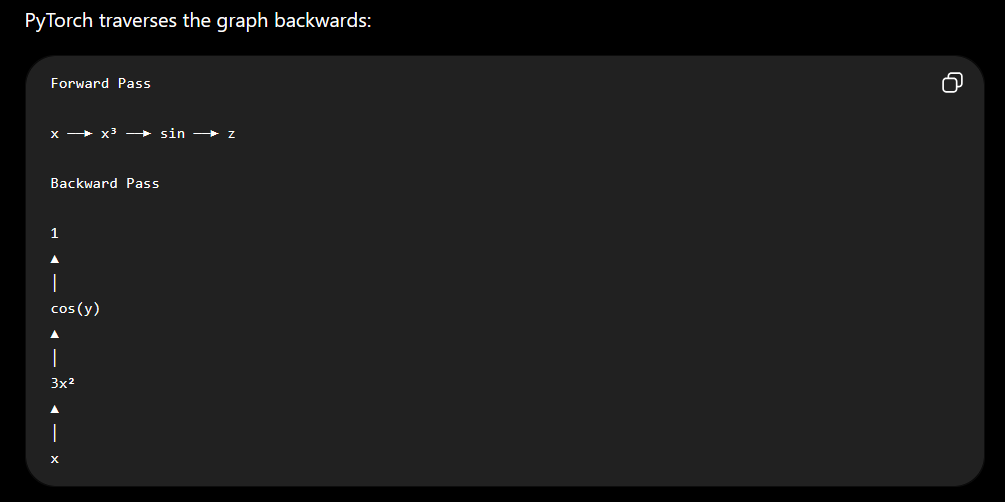

### Using Autograd on actual data

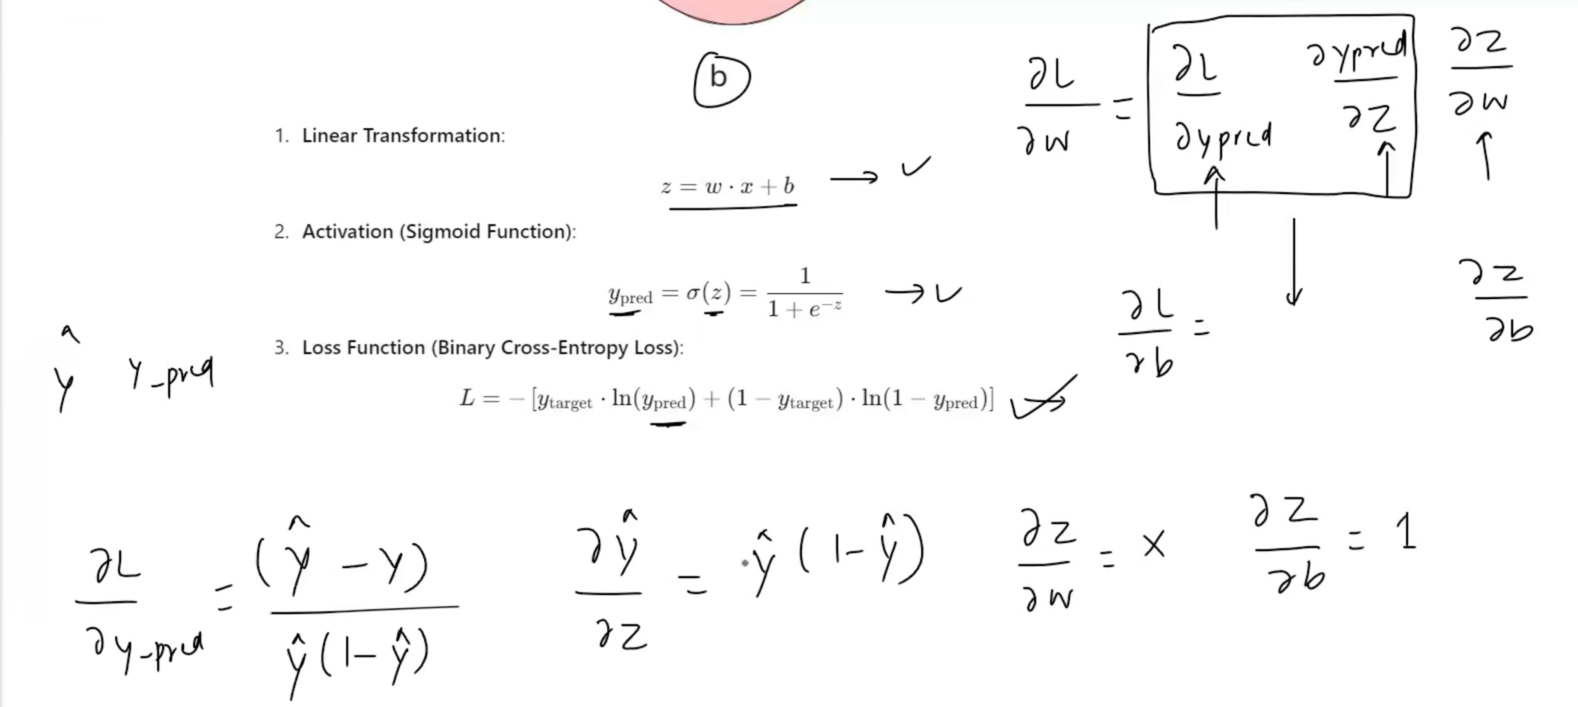

In [32]:
import torch
x = torch.tensor(6.7) # input feature value
y = torch.tensor(0.0) # true label (binary)

# initialize the weight and bias
w = torch.tensor(1.0) #weight
b = torch.tensor(0.0) #bias

In [36]:
# form the binary_cross_entropy loss for scalar

def binary_crossentropy(prediction, target):
    epsilon = 1e-8 # to prevent log0 values
    prediction = torch.clamp(prediction , min=epsilon , max = 1-epsilon) # to get values b/w (0,1)
    return -(target * torch.log(prediction) + (1 - target) * torch.log(1 - prediction))

In [39]:
### Creating a back propagation function for 100 epochs

def backprop(learning_rate = 0.1 , epochs=100):
    # Assign the initial values


    x = torch.tensor(6.7) # input feature value
    y = torch.tensor(0.0) # true label (binary)

    # initialize the weight and bias
    w = torch.tensor(1.0) #weight
    b = torch.tensor(0.0) #bias

    
    for epoch in range(epochs):

        # forward pass every epoch
        z = w * x + b

        y_pred = torch.sigmoid(z) # this gives us prediction value in prob

        # compute the loss
        loss = binary_crossentropy(prediction = y_pred , target = y)

        print(f'Loss at epoch {epoch+1}-> {loss}')
        print(f'Actual at epoch {epoch+1}-> {y}')
        print(f'Predicted at epoch {epoch+1}-> {y_pred}')


        # All the required gradients
        dloss_dy_pred = (y_pred - y)/ (y_pred*(1-y_pred)) 
        dy_pred_dz = y_pred * (1-y_pred)
        dz_dw = x
        dz_db = 1.0

        # Let us now compute the dloss_dw and dloss_db

        dloss_dw = dloss_dy_pred * dy_pred_dz * dz_dw
        dloss_db = dloss_dy_pred * dy_pred_dz * dz_db
        print(f'Change in weight at epoch {epoch+1}-> {dloss_dw}')
        print(f'Change in bias at epoch {epoch+1}-> {dloss_db}')

        # Let us update the weight and bias using gradient descent
        w = w - learning_rate * dloss_dw
        b = b - learning_rate * dloss_db

        print(f'Updated Weight -> {w}')
        print(f'Updated bias -> {b}')

        print('='*100)


In [40]:
backprop(learning_rate=0.1 , epochs=100)

Loss at epoch 1-> 6.701176166534424
Actual at epoch 1-> 0.0
Predicted at epoch 1-> 0.998770534992218
Change in weight at epoch 1-> 6.691762447357178
Change in bias at epoch 1-> 0.998770534992218
Updated Weight -> 0.33082371950149536
Updated bias -> -0.09987705200910568
Loss at epoch 2-> 2.2303595542907715
Actual at epoch 2-> 0.0
Predicted at epoch 2-> 0.8925102353096008
Change in weight at epoch 2-> 5.979818344116211
Change in bias at epoch 2-> 0.8925102353096008
Updated Weight -> -0.2671581506729126
Updated bias -> -0.1891280710697174
Loss at epoch 3-> 0.1294439285993576
Actual at epoch 3-> 0.0
Predicted at epoch 3-> 0.1214161366224289
Change in weight at epoch 3-> 0.8134880661964417
Change in bias at epoch 3-> 0.1214161291718483
Updated Weight -> -0.34850695729255676
Updated bias -> -0.20126968622207642
Loss at epoch 4-> 0.07618431001901627
Actual at epoch 4-> 0.0
Predicted at epoch 4-> 0.073354572057724
Change in weight at epoch 4-> 0.4914756119251251
Change in bias at epoch 4-> 0.0

In [29]:
# forward pass
z = w * x + b

y_pred = torch.sigmoid(z) # this gives us prediction value in prob

# compute the loss
loss = binary_crossentropy(prediction = y_pred , target = y)

print(f'Loss -> {loss}')
print(f'Actual -> {y}')
print(f'Predicted -> {y_pred}')

Loss -> 6.701176166534424
Actual -> 0.0
Predicted -> 0.998770534992218


### Let us now do back propagation and update the weight and bias

dl_dw = dl_d(y_pred) * d(y_pred)_dz * dz_dw                                                                    
dl_db = dl_d(y_pred) * d(y_pred)_dz * dz_db


In [30]:
dloss_dy_pred = (y_pred - y)/ (y_pred*(1-y_pred)) # All the required gradients
dy_pred_dz = y_pred * (1-y_pred)
dz_dw = x
dz_db = 1.0

# Let us now compute the dloss_dw and dloss_db

dloss_dw = dloss_dy_pred * dy_pred_dz * dz_dw
dloss_db = dloss_dy_pred * dy_pred_dz * dz_db
print(f'Change in weight -> {dloss_dw}')
print(f'Change in bias -> {dloss_db}')



Change in weight -> 6.691762447357178
Change in bias -> 0.998770534992218


In [31]:
# Let us update the weight and bias using gradient descent
learning_rate = 0.1
w = w - learning_rate * dloss_dw
b = b - learning_rate * dloss_db

print(f'Updated Weight -> {w}')
print(f'Updated bias -> {b}')

Updated Weight -> 0.33082371950149536
Updated bias -> -0.09987705200910568
